**PROJECT-8 JOB MARKET ANALYSIS AND RECOMMENDATION

In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\all_upwork_jobs_2024-02-07-2024-03-24.csv")
df.head()

,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country
0,Experienced Media Buyer For Solar Pannel and R...,https://www.upwork.com/jobs/Experienced-Media-...,2024-02-17 09:09:54+00:00,False,NaN,NaN,500.0,NaN
1,Full Stack Developer,https://www.upwork.com/jobs/Full-Stack-Develop...,2024-02-17 09:09:17+00:00,False,NaN,NaN,1100.0,United States
2,SMMA Bubble App,https://www.upwork.com/jobs/SMMA-Bubble-App_%7...,2024-02-17 09:08:46+00:00,True,10.0,30.0,NaN,United States
3,Talent Hunter Specialized in Marketing,https://www.upwork.com/jobs/Talent-Hunter-Spec...,2024-02-17 09:08:08+00:00,True,NaN,NaN,NaN,United States
4,Data Engineer,https://www.upwork.com/jobs/Data-Engineer_%7E0...,2024-02-17 09:07:42+00:00,False,NaN,NaN,650.0,India


DATA EXPLORE

In [4]:
df.shape

(244828, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244828 entries, 0 to 244827
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   title           244827 non-null  object 
 1   link            244827 non-null  object 
 2   published_date  244828 non-null  object 
 3   is_hourly       244828 non-null  bool   
 4   hourly_low      102422 non-null  float64
 5   hourly_high     98775 non-null   float64
 6   budget          103891 non-null  float64
 7   country         239751 non-null  object 
dtypes: bool(1), float64(3), object(4)
memory usage: 13.3+ MB


In [6]:
df.describe()

,hourly_low,hourly_high,budget
count,102422.000000,98775.000000,103891.000000
mean,17.339644,41.970610,911.473564
std,18.140065,47.850892,15729.738834
min,3.000000,3.000000,5.000000
25%,8.000000,20.000000,25.000000
50%,15.000000,30.000000,100.000000
75%,20.000000,50.000000,300.000000
max,998.000000,999.000000,1000000.000000


# this shows a lot of difference between the values of hourly_low, high and budget which indicates 50% data is missing

# Handling missing values

In [8]:
df.isnull().sum()

title                  1
link                   1
published_date         0
is_hourly              0
hourly_low        142406
hourly_high       146053
budget            140937
country             5077
dtype: int64

In [9]:
df = df.dropna(subset=['title'])

In [10]:
df['country'] = df['country'].fillna('Unknown')

# Split Data

In [12]:
hourly_jobs = df[df['is_hourly'] == True].copy()
fixed_jobs = df[df['is_hourly'] == False].copy()

In [14]:
hourly_jobs['hourly_low'] = hourly_jobs['hourly_low'].fillna(hourly_jobs['hourly_high'])
hourly_jobs['hourly_high'] = hourly_jobs['hourly_high'].fillna(hourly_jobs['hourly_low'])

# TASK-1- ANALYZE THE CORRELATION BETWEEN JOB TITLES AND OFFERED SALARIES

In [15]:
hourly_jobs['avg_hourly'] = (hourly_jobs['hourly_low'] + hourly_jobs['hourly_high'])/2

In [16]:
fixed_jobs = fixed_jobs.dropna(subset=['budget'])

In [17]:
hourly_jobs.shape
fixed_jobs.shape

(103891, 8)

In [18]:
df = hourly_jobs.copy()

In [35]:
def categorize_job(title):
    title = title.lower()
    if any (word in title for word in ['developer', 'python','web','php','html','development','ava','react','node','css','web','app','c++','c programmer','sql']):
        return 'Development'
    elif any (word in title for word  in ['design','designer','ui','ux','logo','graphic','photoshop','artist']):
        return 'Design'
    elif any (word in title for word in ['data','analysis','analytics','machine','learning','ai','ml','excel']):
        return 'Data/AI'
    elif any (word in title for word in ['marketing','social','facebook','ads','ad','instagram','campaign','media buyer','newsletter']):
        return 'Marketing'
    elif any (word in title for word in ['seo','content','writing','writer','blog','copy','search','researcher']):
        return 'SEO/Content'
    elif any (word in title for word in ['shopify','amazon','ecommerce','store','woocommerce']):
        return 'E-commerce'
    elif any (word in title for word in ['video','editing','youtube',]):
        return 'Video Editing'
    elif any (word in title for word in ['assistant','virtual assistant','admin','support','crm']):
        return 'Virtual/Admin'
    elif any (word in title for word in ['data entry','typing']):
        return 'Data Entry'
    elif any (word in title for word in ['translation','translator','language']):
        return 'Translation'
    elif any (word in title for word in ['finance','account','bookkeeping','billing']):
        return 'Finance'
    elif any (word in title for word in ['sales','lead','b2b']):
        return 'Sales'
    elif any (word in title for word in ['tutor','teaching','course']):
        return 'Education'
    else:
        return 'Other'
    

In [36]:
df['category'] = df['title'].apply(categorize_job)

In [37]:
df['category'].value_counts()

category
Development      32079
Other            31383
Design           19407
Marketing        19218
Data/AI          12930
SEO/Content       8000
Video Editing     6022
Virtual/Admin     4005
E-commerce        2623
Sales             1840
Finance           1668
Translation       1237
Education          493
Data Entry          31
Name: count, dtype: int64

# most job roles were successfully categorized into major domains, a portion of job remained in the 'other' category due to highly diverse job titles. Further categorization was avoided to maintain modelsimplicity and interpretability

#TASK-1 ANALYZE THE CORRELATION BETWEEN JOB TITLES KEYWORDS AND OFFERED SALARIES

In [39]:
category_salary = df.groupby('category')['avg_hourly'].mean().sort_values(ascending=False)
print(category_salary)

category
Sales            42.651327
Other            34.496078
Data Entry       32.120000
Data/AI          29.549201
Design           29.439316
Development      28.087773
SEO/Content      27.961841
Marketing        26.667748
Finance          25.692101
E-commerce       25.527662
Video Editing    25.293881
Translation      23.448646
Education        22.554321
Virtual/Admin    16.404340
Name: avg_hourly, dtype: float64


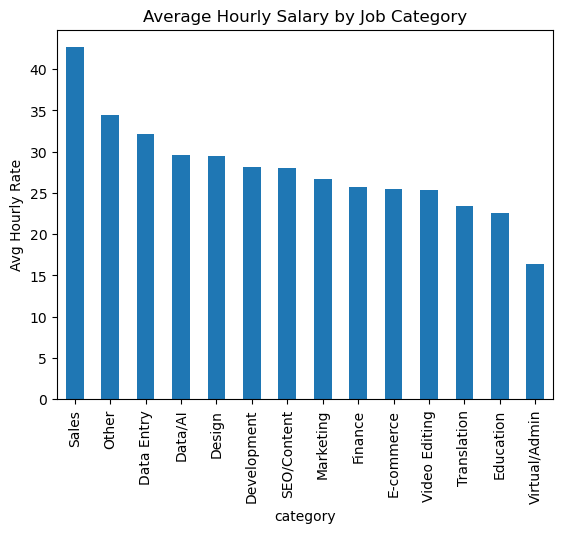

In [41]:
import matplotlib.pyplot as plt
category_salary.plot(kind='bar')
plt.title("Average Hourly Salary by Job Category")
plt.ylabel("Avg Hourly Rate")
plt.show()

TASK-2 IDENTIFY EMERGING JOB CATEGORIES BASED ON POSTING FREQUENCY

In [43]:
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')
df['month'] = df['published_date'].dt.to_period('M')

C:\Users\Admin\AppData\Local\Temp\ipykernel_4948\3241820071.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['published_date'].dt.to_period('M')


In [44]:
trend_data = df.groupby(['month','category']).size().unstack().fillna(0)

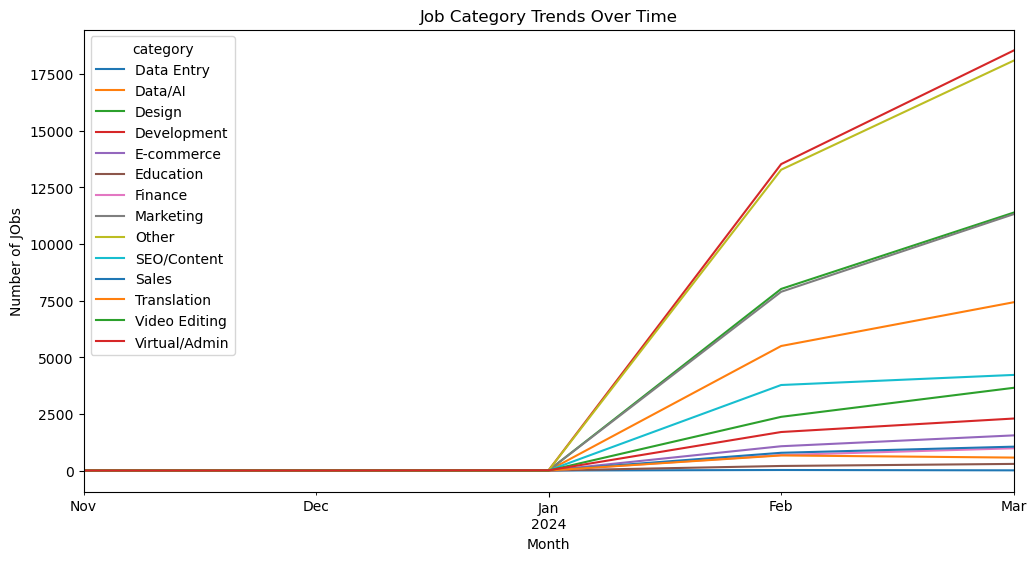

In [45]:
trend_data.plot(figsize=(12,6))
plt.title("Job Category Trends Over Time")
plt.xlabel("Month")
plt.ylabel("Number of JObs")
plt.show()

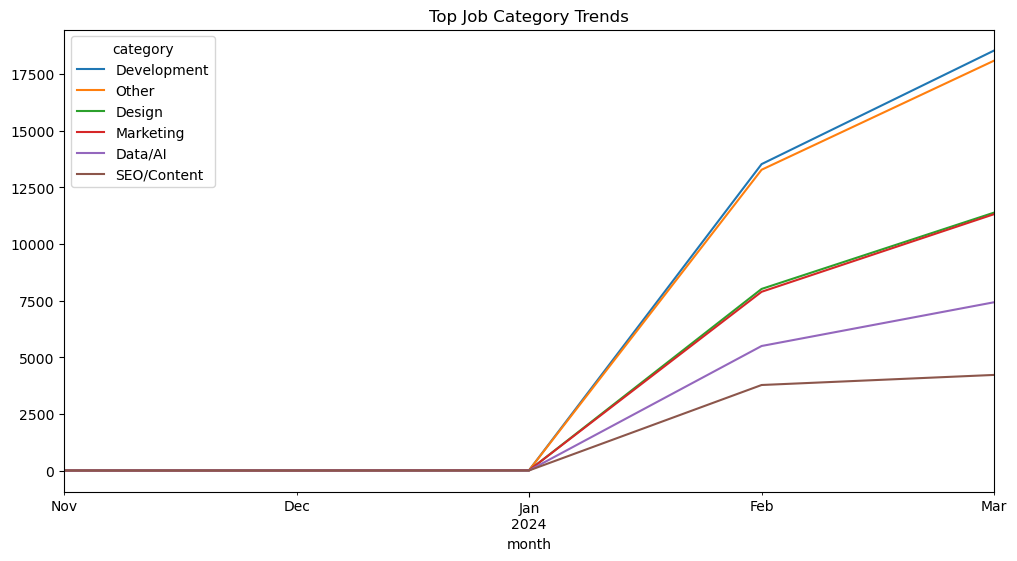

In [46]:
top_categories = df['category'].value_counts().head(6).index
trend_data[top_categories].plot(figsize=(12,6))
plt.title("Top Job Category Trends")
plt.show()

In [48]:
growth = trend_data.diff().mean().sort_values(ascending=False)
print(growth)

category
Development      4635.00
Other            4523.25
Design           2846.25
Marketing        2828.75
Data/AI          1857.00
SEO/Content      1055.00
Video Editing     912.75
Virtual/Admin     573.75
E-commerce        387.75
Sales             263.25
Finance           245.25
Translation       142.75
Education          73.00
Data Entry          2.00
dtype: float64


# Reflects the recent job postings rather than a true historical trend

TASK-3 PREDICT HIGH DEMAND JOB ROLES BY ANALYSING JOB POSTING PATTERNS OVER THE TIME

In [49]:
trend_data.index = trend_data.index.to_timestamp()

In [50]:
data_ml = trend_data.reset_index().melt(id_vars='month', var_name='category', value_name='job_count')

In [51]:
data_ml['month_num'] = data_ml['month'].dt.month

In [52]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data_ml['category_encoded'] = le.fit_transform(data_ml['category'])

In [53]:
X = data_ml[['month_num','category_encoded']]
y = data_ml['job_count']

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
model = LinearRegression()

In [56]:
model.fit(X_train, y_train)

LinearRegression()

In [57]:
y_pred = model.predict(X_test)

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [59]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2716.5195593111157
RMSE: 3595.3950992222035
R2 Score: 0.12017067671625425


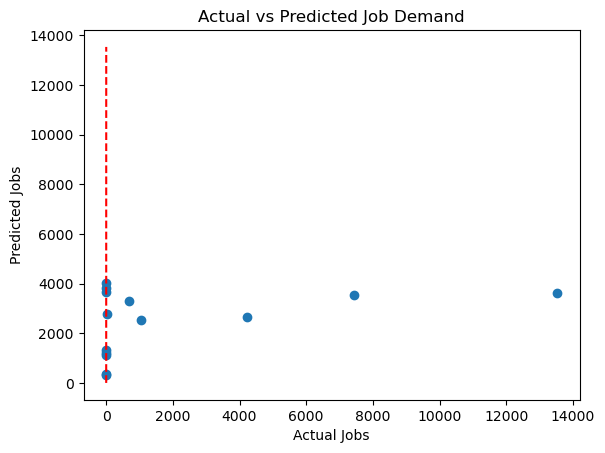

In [62]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Jobs")
plt.ylabel("Predicted Jobs")
plt.title("Actual vs Predicted Job Demand")
plt.show()

In [61]:
data_ml['predicted'] = model.predict(X)
trend_pred = data_ml.groupby(['month','category',])[['job_count','predicted']].mean().reset_index()

In [64]:
top_categories = data_ml['category'].value_counts().head(5).index
for cat in top_categories:
    temp = trend_pred[trend_pred['category'] == cat]

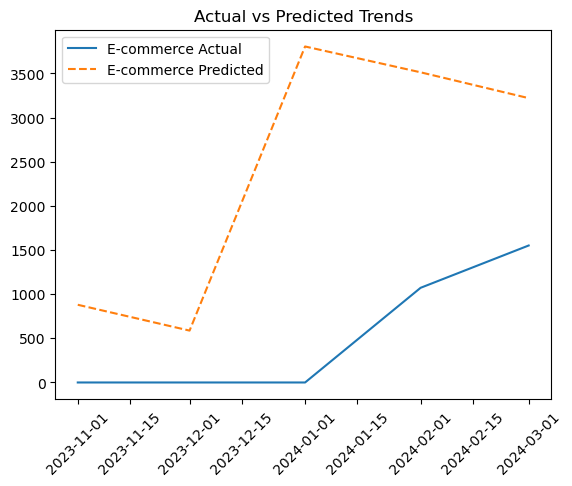

In [66]:
plt.plot(temp['month'], temp['job_count'], label=f"{cat} Actual")
plt.plot(temp['month'], temp['predicted'], linestyle='dashed', label=f"{cat} Predicted")
plt.legend()
plt.title("Actual vs Predicted Trends")
plt.xticks(rotation=45)
plt.show()

In [67]:
data_ml['year'] = data_ml['month'].dt.year

In [68]:
from sklearn.preprocessing import LabelEncoder

In [69]:
le = LabelEncoder()

In [70]:
data_ml['category_encoded'] = le.fit_transform(data_ml['category'])

In [71]:
data_ml[['category','category_encoded']].head()

,category,category_encoded
0,Data Entry,0
1,Data Entry,0
2,Data Entry,0
3,Data Entry,0
4,Data Entry,0


In [72]:
data_ml['category_encoded'].nunique()

14

In [73]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)
               

{'Data Entry': 0, 'Data/AI': 1, 'Design': 2, 'Development': 3, 'E-commerce': 4, 'Education': 5, 'Finance': 6, 'Marketing': 7, 'Other': 8, 'SEO/Content': 9, 'Sales': 10, 'Translation': 11, 'Video Editing': 12, 'Virtual/Admin': 13}


In [74]:
data_ml['category'].value_counts()

category
Data Entry       5
Data/AI          5
Design           5
Development      5
E-commerce       5
Education        5
Finance          5
Marketing        5
Other            5
SEO/Content      5
Sales            5
Translation      5
Video Editing    5
Virtual/Admin    5
Name: count, dtype: int64

In [75]:
data_ml.head()

,month,category,job_count,month_num,category_encoded,predicted,year
0,2023-11-01,Data Entry,0.0,11,0,1331.240851,2023
1,2023-12-01,Data Entry,0.0,12,0,1038.782849,2023
2,2024-01-01,Data Entry,0.0,1,0,4255.820868,2024
3,2024-02-01,Data Entry,23.0,2,0,3963.362867,2024
4,2024-03-01,Data Entry,8.0,3,0,3670.904865,2024


In [76]:
X = data_ml[['month_num','year','category_encoded']]

In [77]:
y = data_ml[['month_num','year','category_encoded']]

In [78]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [80]:
y_pred = model.predict(X_test)

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.2938095238095238
RMSE: 0.43427553246209744
R2 Score: 0.9898840359888709


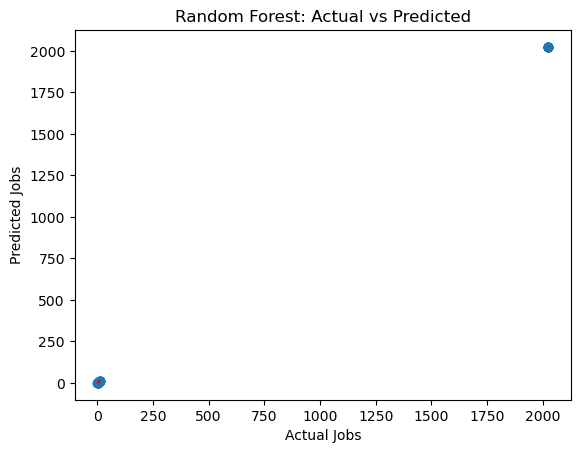

In [83]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Jobs")
plt.ylabel("Predicted Jobs")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [84]:
data_ml['predicted'] = model.predict(X)

In [85]:
trend_pred = data_ml.groupby(['month','category',])[['job_count','predicted']].mean().reset_index()

In [88]:
top_categories = data_ml['category'].value_counts().head(2).index

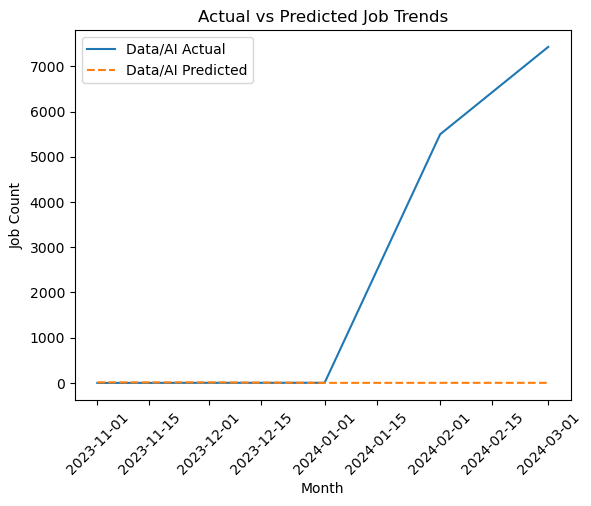

In [89]:
import matplotlib.pyplot as plt
for cat in top_categories:
    temp = trend_pred[trend_pred['category'] ==cat]
plt.plot(temp['month'], temp['job_count'], label=f"{cat} Actual")
plt.plot(temp['month'], temp['predicted'], linestyle='dashed', label=f"{cat} Predicted")
plt.legend()
plt.title("Actual vs Predicted Job Trends")
plt.xlabel("Month")
plt.ylabel("Job Count")
plt.xticks(rotation=45)
plt.show()

#TASK-4 COMPARE HOURLY RATES ACROSS COUNTRIES

In [91]:
df = hourly_jobs.copy()

In [93]:
country_salary = df.groupby('country')['avg_hourly'].mean().sort_values(ascending=False)

In [94]:
print(country_salary.head(10))

country
Laos                        151.750000
Eritrea                     100.000000
Malawi                       75.500000
Netherlands Antilles         61.250000
Malaysia                     46.825373
Turks and Caicos Islands     46.625000
Thailand                     41.505085
Liechtenstein                41.250000
British Virgin Islands       40.222222
Zambia                       39.500000
Name: avg_hourly, dtype: float64


In [95]:
!pip install plotly

In [96]:
import plotly.express as px

In [97]:
df = hourly_jobs.copy()
country_salary = df.groupby('country')['avg_hourly'].mean().reset_index()

In [100]:
country_salary['country'] = country_salary['country'].replace({'USA': 'United States', 'UK': 'United Kingdom'})

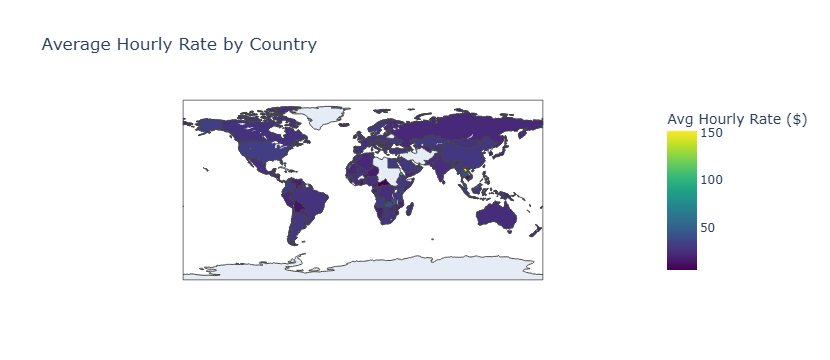

In [103]:
fig = px.choropleth( country_salary, locations='country',locationmode='country names',color='avg_hourly',hover_name='country',hover_data={'avg_hourly':True},color_continuous_scale='Viridis', title='Average Hourly Rate by Country')
fig.update_layout(coloraxis_colorbar=dict(title="Avg Hourly Rate ($)"))
fig.show()

In [105]:
print(country_salary.sort_values(by='avg_hourly', ascending=False).head(10))

                      country  avg_hourly
99                       Laos  151.750000
57                    Eritrea  100.000000
108                    Malawi   75.500000
128      Netherlands Antilles   61.250000
109                  Malaysia   46.825373
185  Turks and Caicos Islands   46.625000
178                  Thailand   41.505085
102             Liechtenstein   41.250000
26     British Virgin Islands   40.222222
200                    Zambia   39.500000


TASK-5 CREATE A JOB RECOMMENDATION ENGINE BASED ON CURRENT JOB POSTINGS

In [107]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [115]:
df = hourly_jobs.copy()
df = df[['title']].dropna()
df = df.sample(20000)

In [119]:
df = df.reset_index(drop=True)

In [120]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['title'])

In [121]:
import numpy as np

In [124]:
def recommend_jobs (query, tfidf_vectorizer, tifidf_matrix, top_n=5):
    query_vec = tfidf_vectorizer.transform([query])
    cosine_similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    related_docs_indices = cosine_similarities.argsort()[:-6:-1]
    return df.iloc[related_docs_indices]

In [125]:
recommend_jobs("data analyst",tfidf, tfidf_matrix, df)

,title
6691,Data analyst
585,Data Analyst
4596,Data Analyst
19349,Data analyst
9562,Data Analyst


In [126]:
recommend_jobs("python developer", tfidf, tfidf_matrix, df)

,title
2525,Python developer
13298,Python Developer
3726,Python Developer
1982,Python developer
17640,Python Developer


In [127]:
recommend_jobs("digital marketing", tfidf, tfidf_matrix, df)

,title
9690,Digital marketing
19996,Digital Marketing
8794,Comercializador via marketing digital
1246,Digital Marketing
5279,Digital marketing


# TASK-6 TRACK CHANGES IN JOB MARKET DYNAMICS OVER THE MONTHS

In [128]:
# Extract months

In [130]:
df = hourly_jobs.copy()

In [131]:
df_trend = hourly_jobs.copy()

In [132]:
df[['published_date']].head()

,published_date
2,2024-02-17 09:08:46+00:00
3,2024-02-17 09:08:08+00:00
5,2024-02-17 09:07:41+00:00
7,2024-02-17 09:07:05+00:00
8,2024-02-17 09:06:24+00:00


In [137]:
df = hourly_jobs.copy()

In [144]:
def categorize(title):
    title = str(title).lower()
    if 'data' in title:
        return 'Data/AI'
    elif 'python' in title or'developer' in title or 'web' in title:
        return 'Development'
    elif 'design' in title:
        return 'Design'
    elif 'marketing' in title or 'seo' in title:
        return 'Marketing'
    elif 'writing' in title or 'content' in title:
        return 'Content'
    elif 'virtual assistant' in title or 'admin' in title:
        return 'Admin'
    else:
        return 'Other'

In [145]:
df['category'] = df['title'].apply(categorize)

In [146]:
top_categories = df['category'].value_counts().head(5).index

In [149]:
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')
df['month'] = df['published_date'].dt.to_period('M')

C:\Users\Admin\AppData\Local\Temp\ipykernel_4948\3241820071.py:2: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



In [150]:
print(df.columns)

Index(['title', 'link', 'published_date', 'is_hourly', 'hourly_low',
       'hourly_high', 'budget', 'country', 'avg_hourly', 'category', 'month'],
      dtype='object')


In [151]:
trend_data = df.groupby(['month','category']).size().unstack().fillna(0)

In [158]:
trend_clean = trend_data.replace(0, np.nan)

In [159]:
growth = trend_clean[top_categories].pct_change().mean().sort_values(ascending=False)

In [160]:
growth = growth.fillna(0)

In [161]:
print(growth)

category
Design         1170.454036
Development     666.677447
Marketing       348.032751
Data/AI         244.951588
Other           221.440322
dtype: float64


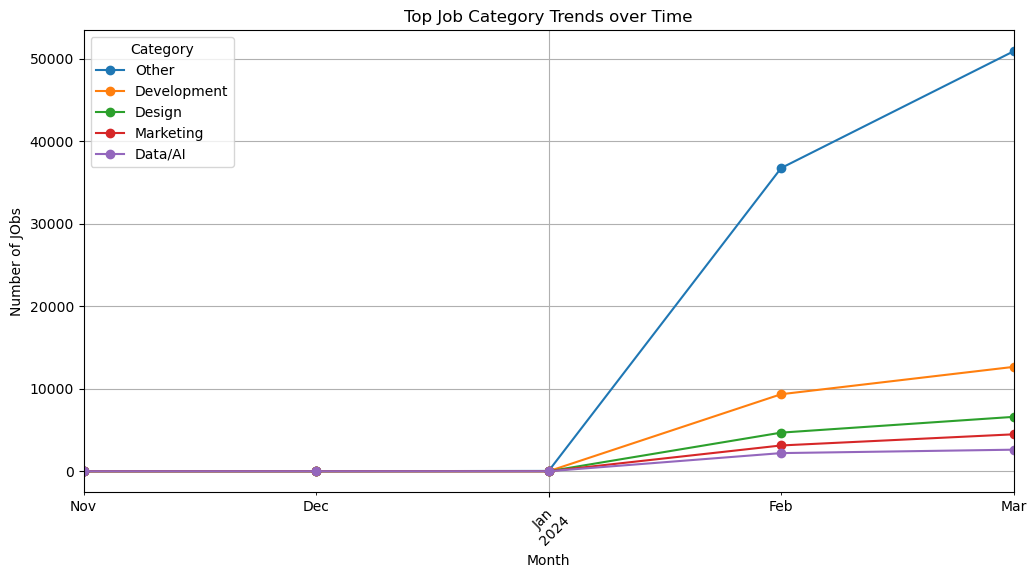

In [162]:
import matplotlib.pyplot as plt
trend_data[top_categories].plot(figsize=(12,6), marker='o')
plt.title("Top Job Category Trends over Time")
plt.xlabel("Month")
plt.ylabel("Number of JObs")
plt.legend(title="Category")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [163]:
print("Growth Rate by Category:")
print(growth)

Growth Rate by Category:
category
Design         1170.454036
Development     666.677447
Marketing       348.032751
Data/AI         244.951588
Other           221.440322
dtype: float64


In [164]:
print("\n Fastest Growing Category:")
print(growth.idxmax())


 Fastest Growing Category:
Design


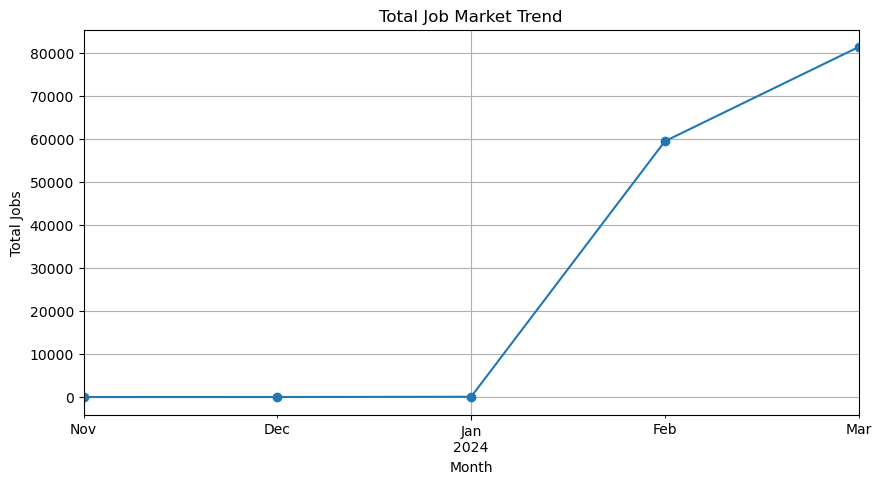

In [166]:
monthly_total = trend_data.sum(axis=1)
monthly_total.plot(figsize=(10,5), marker='o')
plt.title("Total Job Market Trend")
plt.xlabel("Month")
plt.ylabel("Total Jobs")
plt.grid(True)
plt.show()

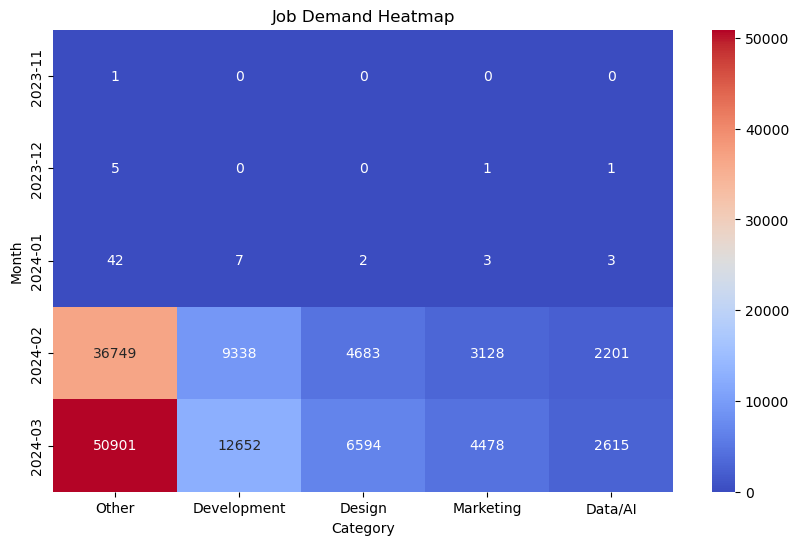

In [168]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(trend_data[top_categories], annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Job Demand Heatmap")
plt.xlabel("Category")
plt.ylabel("Month")
plt.show()

# overall trend indicates rising demand in technical roles

#TASK-7 INVESTIGATE TRENDS IN REMOTE JOBS

In [ ]:
# Hourly vs Fixed jobs

In [172]:
df['job_type'] = df['is_hourly'].map({1: 'Hourly', 0:'Fixed'})

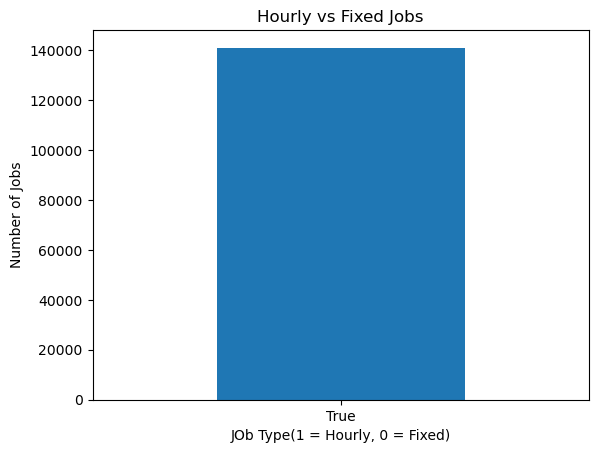

In [173]:
job_type = df['is_hourly'].value_counts()
job_type.plot(kind='bar')
plt.title("Hourly vs Fixed Jobs")
plt.xlabel("JOb Type(1 = Hourly, 0 = Fixed)")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=0)
plt.show()

# The Dataset contains omly hourly jobs which reflects the nature of Freelance platforms where hourly contracts are commom

In [ ]:
# Top countries offering Jobs

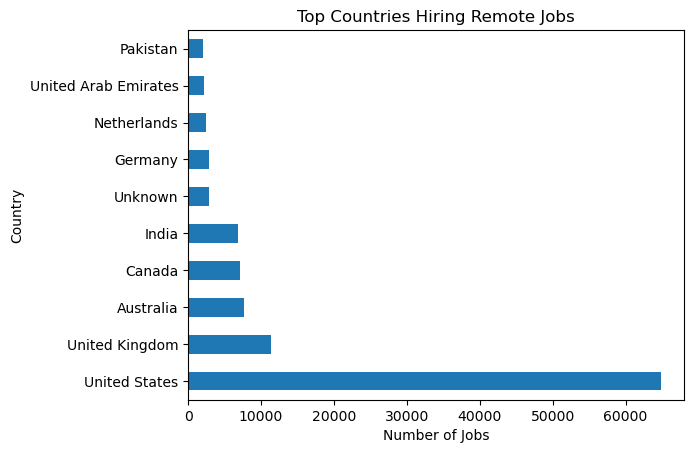

In [174]:
top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind='barh')
plt.title("Top Countries Hiring Remote Jobs")
plt.xlabel("Number of Jobs")
plt.ylabel("Country")
plt.show()

In [ ]:
# Average hourly Rate by Country

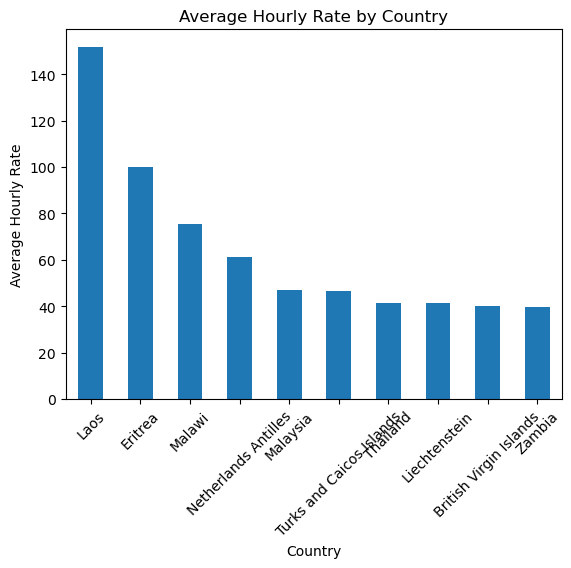

In [176]:
avg_rate = df.groupby('country')['avg_hourly'].mean().sort_values(ascending=False).head(10)
avg_rate.plot(kind='bar')
plt.title("Average Hourly Rate by Country")
plt.xlabel("Country")
plt.ylabel("Average Hourly Rate")
plt.xticks(rotation=45)
plt.show()

# The analysis shows that the United States has the highest number of Remote Jobs, however, average hourly rates are high in small countries like Laos.....

TASK-8 PREDICT FUTURE JOB MARKET TRENDS

In [178]:
trend_data = df.groupby(['month', 'category']).size().unstack().fillna(0)

In [179]:
trend_data = trend_data.reset_index()
trend_data['month_num'] = range(len(trend_data))

In [180]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

In [ ]:
# Train Model

In [181]:
future_predictions = {}
for col in trend_data.columns[1:-1]:
    X = trend_data[['month_num']]
    y = trend_data[col]
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

RandomForestRegressor(random_state=42)

In [183]:
import pandas as pd

In [185]:
future_months = pd.DataFrame({'month_num': [len(trend_data),len(trend_data)+1]})
preds = model.predict(future_months)

In [186]:
future_predictions[col] = preds

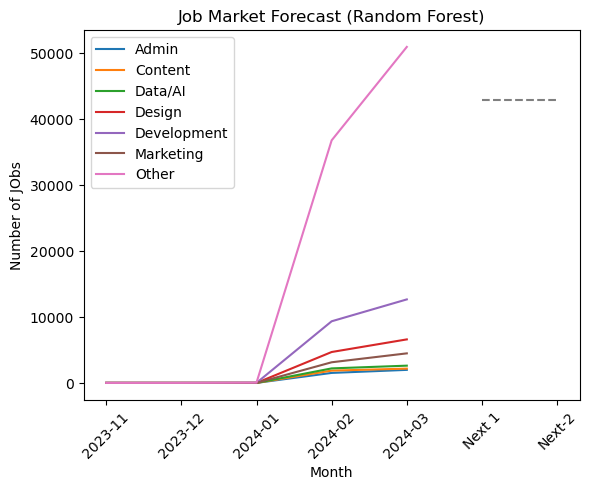

In [191]:
import matplotlib.pyplot as plt
for col in trend_data.columns:
    if col not in ['month', 'month_num']:
        plt.plot(trend_data['month'].astype(str), trend_data[col], label=col)
future_x = ['Next 1', 'Next-2' ]
for col, preds in future_predictions.items():
    plt.plot(future_x, preds, linestyle='dashed')
plt.legend()
plt.title("Job Market Forecast (Random Forest)")
plt.xlabel("Month")
plt.ylabel("Number of JObs")
plt.xticks(rotation=45)
plt.show()

In [192]:
df.to_csv("final_clean_data_project8.csv", index=False)

In [193]:
!pip install streamlit

In [1]:
import pickle

In [2]:
import os
os.getcwd()

'C:\\Users\\Admin\\Phython'

In [3]:
os.listdir()

['.ipynb_checkpoints',
 'app.py',
 'best_gb_model.pk1',
 'calculator.ipynb',
 'calculator.py',
 'CAPSTONE PROJECT E-COMMERCE-1.ipynb',
 'Capstone Project-E-commerce.ipynb',
 'cleaned_mobile_data.csv',
 'cleaned_property1_data.csv',
 'cleaned_property_data.csv',
 'cleaned_property_data.pkl',
 'df_encoded.pkl',
 'final_clean_data_project8.csv',
 'final_house_data.csv',
 'final_mobile_gb_model.pk1',
 'final_model.pk1',
 'glove.6B.100d.txt',
 'glove.6B.200d.txt',
 'glove.6B.300d.txt',
 'glove.6B.50d.txt',
 'glove.zip',
 'gradient_boosting_model.pk1',
 'House_Price_Prediction_Project -3.ipynb',
 'KaggleV2-May-2016.csv.zip',
 'model.pk1',
 'model_columns.pk1',
 'practice',
 'processed_housing.csv',
 'Project-7 Twitter prediction',
 'project8_backup.ipynb',
 'Python_Revision_basics',
 'rf_model.pk1',
 'sales_predictions.csv',
 'submission.csv',
 'svm_model.pk1',
 'telecom_user_analysis.ipynb',
 'testdata.jpg',
 'test_data.csv',
 'tfidf_vectorizer.pk1',
 'titanic.ipynb',
 'train_data.csv',
 'U

In [ ]:
!streamlit run app.py --server.headless true --server.port 8501